In [3]:
from openai import AsyncOpenAI
from openai.types.shared.reasoning import Reasoning
from openai.types.responses.tool_param import CodeInterpreter
from openai.types.responses import ResponseTextDeltaEvent

from agents import (
    Agent, 
    Runner, 
    function_tool,
    ItemHelpers,
    ModelSettings, 
    WebSearchTool, 
    CodeInterpreterTool, 
    HostedMCPTool,
    FileSearchTool
)
from agents.extensions.visualization import draw_graph
from agents.mcp import MCPServerStreamableHttp


Quick connection test

In [2]:
client = AsyncOpenAI()
r = await client.responses.create(
    model='gpt-5.1',
    reasoning={'effort': 'none', 'summary': 'detailed'},
    instructions='You are a helpful, to-the-point AI that answers quickly and concisely',
    input=[{'role': 'user', 'content': 'What is the capital of France?'}],
)

print(r.usage)
print(r.output_text)

ResponseUsage(input_tokens=33, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=17, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=50)
Paris is the capital of France.


### Build your agent

Prompt

In [4]:
system_message = """

You are a capable AI assistant helping deal teams in the private equity sector. You have access to tools to conduct deal sourcing. our number one goal is to collect exhaustive information about the presented target company using access to related documents, the internet, external information sources (through MCP servers) and additional context enhancement tools you have access to.

Your task is to gather information - not to format it. You don't have to pay attention to formatting or style, you only exist to collect, gather, present information, that helps the company decide whether the target is an attractive investment opportunity and is worth going deeper, or should be dimissed. This decision is NOT up to you. You are NOT to give suggestion, advice. You are only to PRESENT unbiased, objective information.

"""

Set up MCP server

In [16]:
server = MCPServerStreamableHttp(
    name="Stock Market Tools",
    params={
        "url": "http://localhost:8001/mcp/",  
        "timeout": 30
    },
    cache_tools_list=True,
)

await server.connect()

Set up Agent

In [17]:
agent = Agent(
    name="Deal Sourcing Agent",
    model='gpt-5.1',
    model_settings=ModelSettings(
        reasoning=Reasoning(effort='low', summary="detailed")
    ),
    instructions=system_message,
    mcp_servers=[server], 
    tools=[
        WebSearchTool(search_context_size='medium'),
        CodeInterpreterTool(
            tool_config=CodeInterpreter(
                container={"type": "auto", "file_ids": []},
                type='code_interpreter'
            )
        ),
    ],
)

Let's take a look at it!

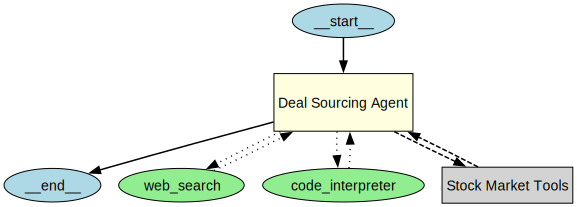

In [18]:
draw_graph(agent)

Run Agent

In [19]:
target_company = "Culver's - Wisconsin based burger chain"
user_message = f"""

Your target company is {target_company}.
Use the available tools to conduct your research. Present your findings in a memo-like writeup, organized into topics.

"""

In [ ]:
async def stream_results(result):
    """
    Stream and display all events from agent execution.
    Handles: Web Search, Code Interpreter, Function calls (MCP tools), Reasoning, and Text output.
    """
    async for ev in result.stream_events():
        # Skip agent updates silently
        if ev.type == "agent_updated_stream_event":
            continue
        
        # Handle raw response events
        if ev.type == "raw_response_event":
            data = ev.data
            event_type = getattr(data, 'type', None)
            
            # 1. Tool call initiated
            if event_type == "response.output_item.added":
                item = data.item
                item_type = getattr(item, 'type', None)
                
                # Web search started
                if item_type == 'web_search_call':
                    action = getattr(item, 'action', None)
                    query = getattr(action, 'query', None) if action else None
                    print(f"🌐 [Web Search] {query if query else 'searching...'}")
                    print('===' * 20)
                    print('\n')
                
                # Code interpreter started
                elif item_type == 'code_interpreter_call':
                    print(f"🐍 [Code Interpreter]")
                    print('===' * 20)
                    print('\n')
                
                # Function call started (these are your MCP tools!)
                elif item_type == 'function_call':
                    name = getattr(item, 'name', 'unknown')
                    print(f"⚙️  [Function] {name}")
                    print('===' * 20)
                    print('\n')
            
            # 2. Function arguments completed
            elif event_type == "response.function_call_arguments.done":
                args = getattr(data, 'arguments', '')
                print(f"   → Args: {args}\n")
            
            # 3. Code interpreter code done
            elif event_type == "response.code_interpreter_call_code.done":
                code = getattr(data, 'code', '')
                if code:
                    print(f"   → Code: {code}\n")
            
            # 4. Tool/item completion
            elif event_type == "response.output_item.done":
                item = data.item
                item_type = getattr(item, 'type', None)
                
                # Web search completed
                if item_type == 'web_search_call':
                    status = getattr(item, 'status', None)
                    if status == 'completed':
                        print(f"✅ [Web Search Complete]")
                        print('===' * 20)
                        print('\n')
                
                # Code interpreter completed
                elif item_type == 'code_interpreter_call':
                    status = getattr(item, 'status', None)
                    if status == 'completed':
                        print(f"✅ [Code Interpreter Complete]")
                        print('===' * 20)
                        print('\n')
                
                # Function call completed (MCP tools)
                elif item_type == 'function_call':
                    status = getattr(item, 'status', None)
                    if status == 'completed':
                        name = getattr(item, 'name', 'unknown')
                        print(f"✅ [Function Complete] {name}")
                        print('===' * 20)
                        print('\n')
                
                # Reasoning completed
                elif item_type == 'reasoning':
                    print(f"🧠 [Reasoning Complete]")
                    if hasattr(item, 'summary') and item.summary:
                        summary_text = '\n'.join([t.text for t in item.summary])
                        print(f"{summary_text}")
                    print('===' * 20)
                    print('\n')
            
            # 5. Text deltas (streaming assistant response)
            elif event_type == "response.output_text.delta":
                delta = getattr(data, 'delta', '')
                if delta:
                    print(delta, end='', flush=True)
            
            # 6. Text done (full text available)
            elif event_type == "response.output_text.done":
                # Text streaming completed, just add newline
                pass
            
            # 7. Reasoning summary
            elif event_type == "response.reasoning_summary_text.done":
                text = getattr(data, 'text', '')
                if text:
                    print(f"\n📝 [Reasoning Summary]")
                    print(text)
                    print('===' * 20)
                    print('\n')
    
    print('\n')  # Final newline
    return result

In [40]:
user_message = 'What tools do you have?'

result = Runner.run_streamed(
    starting_agent=agent,
    input=user_message,
    max_turns=500,
)

In [41]:
result = await stream_results(result)


📝 [Reasoning Summary]
**Explaining tools in context**

I want to clarify that I'm considering various tools like web, Python, and finance tools—though I'm not planning to call any of them right now. I’m thinking about how these tools can fit into the user context around PE sourcing. It’s important to connect the right tools to the user's needs without getting too technical or overwhelming them. I'll focus on providing useful insights based on what's relevant to them.


🧠 [Reasoning Complete]
**Explaining tools in context**

I want to clarify that I'm considering various tools like web, Python, and finance tools—though I'm not planning to call any of them right now. I’m thinking about how these tools can fit into the user context around PE sourcing. It’s important to connect the right tools to the user's needs without getting too technical or overwhelming them. I'll focus on providing useful insights based on what's relevant to them.


Here are the main tool types I can use in this env

In [42]:
print(result.final_output)

Here are the main tool types I can use in this environment and what they’re useful for in a private‑equity / deal-sourcing context:

1) Internet research (`web.run`)
- What it does:
  - General web search (news, company websites, filings, press releases, blogs, forums, etc.).
  - Open specific URLs and scroll/find within them.
  - Basic calculator (for quick numeric checks).
  - Weather, time, sports, etc. (less relevant for deal work).
- How it helps for deals:
  - Identify and profile target companies (business model, products, customers, geographies).
  - Collect competitive landscape data and comparable companies.
  - Pull market/industry reports and commentary.
  - Check recent news: M&A, funding, regulatory issues, management changes, controversies.
  - Verify key facts: HQ location, headcount bands, offices, leadership, product lines.

2) Code execution for internal analysis (`python.exec`)
- What it does:
  - Run Python code in a private environment (not directly visible to you

In [ ]:
server.cleanup()

In [1]:
from  user_memory import extract_user_memory
from openai import AsyncOpenAI
client = AsyncOpenAI()

test_text = "Hi can you help me with my car? It doesn't start"
test_answer = await extract_user_memory(test_text, client=client)

In [2]:
test_answer.model_dump()

{'primary_intent': 'A car owner seeking assistance for a breakdown.',
 'secondary_intents': ["Experiencing trouble with a car that won't start.",
  'Looking for guidance or support with car repairs.']}